# 轨迹单元二维嵌入散点图

读取 `output/time_series_hierarchical/trajectory_units_dimred_2d_hier_dtw.csv`，将 **UMAP / t-SNE / PCA** 中的一组二维坐标画成散点图。

**使用方式**：先运行下方「参数」单元，再运行「绘图」单元。改图时主要改参数单元中的变量即可。

**前提**：在仓库根目录启动 Jupyter，保证相对路径可用。


In [5]:
# --- Parameters (edit here for fine control) ---

from __future__ import annotations

from pathlib import Path

# Repo root: parent of this notebook if notebook lives at repo root
REPO_ROOT = Path.cwd()
CSV_PATH = REPO_ROOT / "output/time_series_hierarchical/trajectory_units_dimred_2d_hier_dtw.csv"

# Which 2D embedding to plot: "umap" | "tsne" | "pca"
DIMRED = "umap"

# Figure layout
FIGSIZE_INCH = (9.0, 7.5)
DPI = 600
# Set to a Path or str to save; None = only show interactively
SAVE_FIG_PATH: str | Path | None = "output/visualize"
# e.g. REPO_ROOT / "output/time_series_hierarchical/trajectory_scatter_umap.png"
# Raster export dpi (None = use DPI above)
SAVE_FIG_DPI: int | None = 600

# Point appearance (non-highlight vs CN/US)
POINT_SIZE_BASE = 32.0
POINT_SIZE_HIGHLIGHT = 78.0
ALPHA_BASE = 1
ALPHA_HIGHLIGHT = 1
EDGE_COLOR = "0.15"
EDGE_WIDTH_BASE = 0.35
EDGE_WIDTH_HIGHLIGHT = 0.55

# Optional tiny jitter to separate exact overlaps (std in data units); 0 = off
JITTER_STD = 0.0
RANDOM_SEED = 0

# Push selected trajectory_cluster groups apart in 2D (after jitter; same units as the embedding).
# For each listed cluster, shift all its points by (factor-1)*(centroid_k - G), where G is the mean
# of centroids of the listed clusters only. factor=1.0 disables. Other clusters are untouched.
SEPARATE_CLUSTER_IDS: frozenset[int] | set[int] | None = frozenset({0, 2, 3})
SEPARATE_CLUSTER_RADIAL_FACTOR = 1.32

# Coloring: "cluster" uses trajectory_cluster; "country" uses country labels
COLOR_BY: str = "cluster"
# Colorblind-friendly qualitative hex (Okabe–Ito + Tol-style extensions). None = use defaults below.
CLUSTER_PALETTE_HEX: list[str] | None = ["#547bb4", "#629c35", "#6c61af","#6f6f6f", "#c0321a", "#dd7c4f"]
COUNTRY_PALETTE_HEX: list[str] | None = []

_DEFAULT_CLUSTER_HEX_OKABE_ITO = [
    "#E69F00",
    "#56B4E9",
    "#009E73",
    "#F0E442",
    "#0072B2",
    "#D55E00",
    "#CC79A7",
    "#000000",
]
_DEFAULT_COUNTRY_HEX_EXTENDED = _DEFAULT_CLUSTER_HEX_OKABE_ITO + [
    "#332288",
    "#88CCEE",
    "#44AA99",
    "#117733",
    "#999933",
    "#DDCC77",
    "#CC6677",
    "#882255",
    "#AA4499",
    "#4477AA",
    "#EE6677",
    "#228833",
    "#CCBB44",
    "#AA3377",
]

# Highlight countries (markers drawn on top)
HIGHLIGHT_CN = "CN"
HIGHLIGHT_US = "US"
MARKER_CN = "*"
MARKER_US = "P"
MARKER_OTHERS = "o"
ZORDER_BASE = 1
ZORDER_HIGHLIGHT = 3

# Filters
SELECT_TOPIC: int | None = None  # e.g. 5 for one topic; None = all
# None = all countries; or e.g. ["CN", "US", "JP"]
COUNTRIES_INCLUDE: list[str] | None = None

# Axes & labels
TITLE = ""  # empty -> auto from DIMRED
XLABEL = ""  # empty -> auto
YLABEL = ""  # empty -> auto
GRID = True
GRID_ALPHA = 0
AXIS_EQUAL = False  # True forces equal aspect (can shrink one axis on UMAP)

# Legend: "auto" (cluster/country), "off"
LEGEND: str = "auto"
LEGEND_OUTSIDE = True
LEGEND_FONT_SIZE = 9

# Font (macOS Chinese; change if needed)
FONT_SANS = ["Arial Unicode MS", "PingFang SC", "Noto Sans CJK SC", "DejaVu Sans"]


Saved: D:\Tech-catch-up\catch-up\output\visualize
rows: 662 | topics: 50


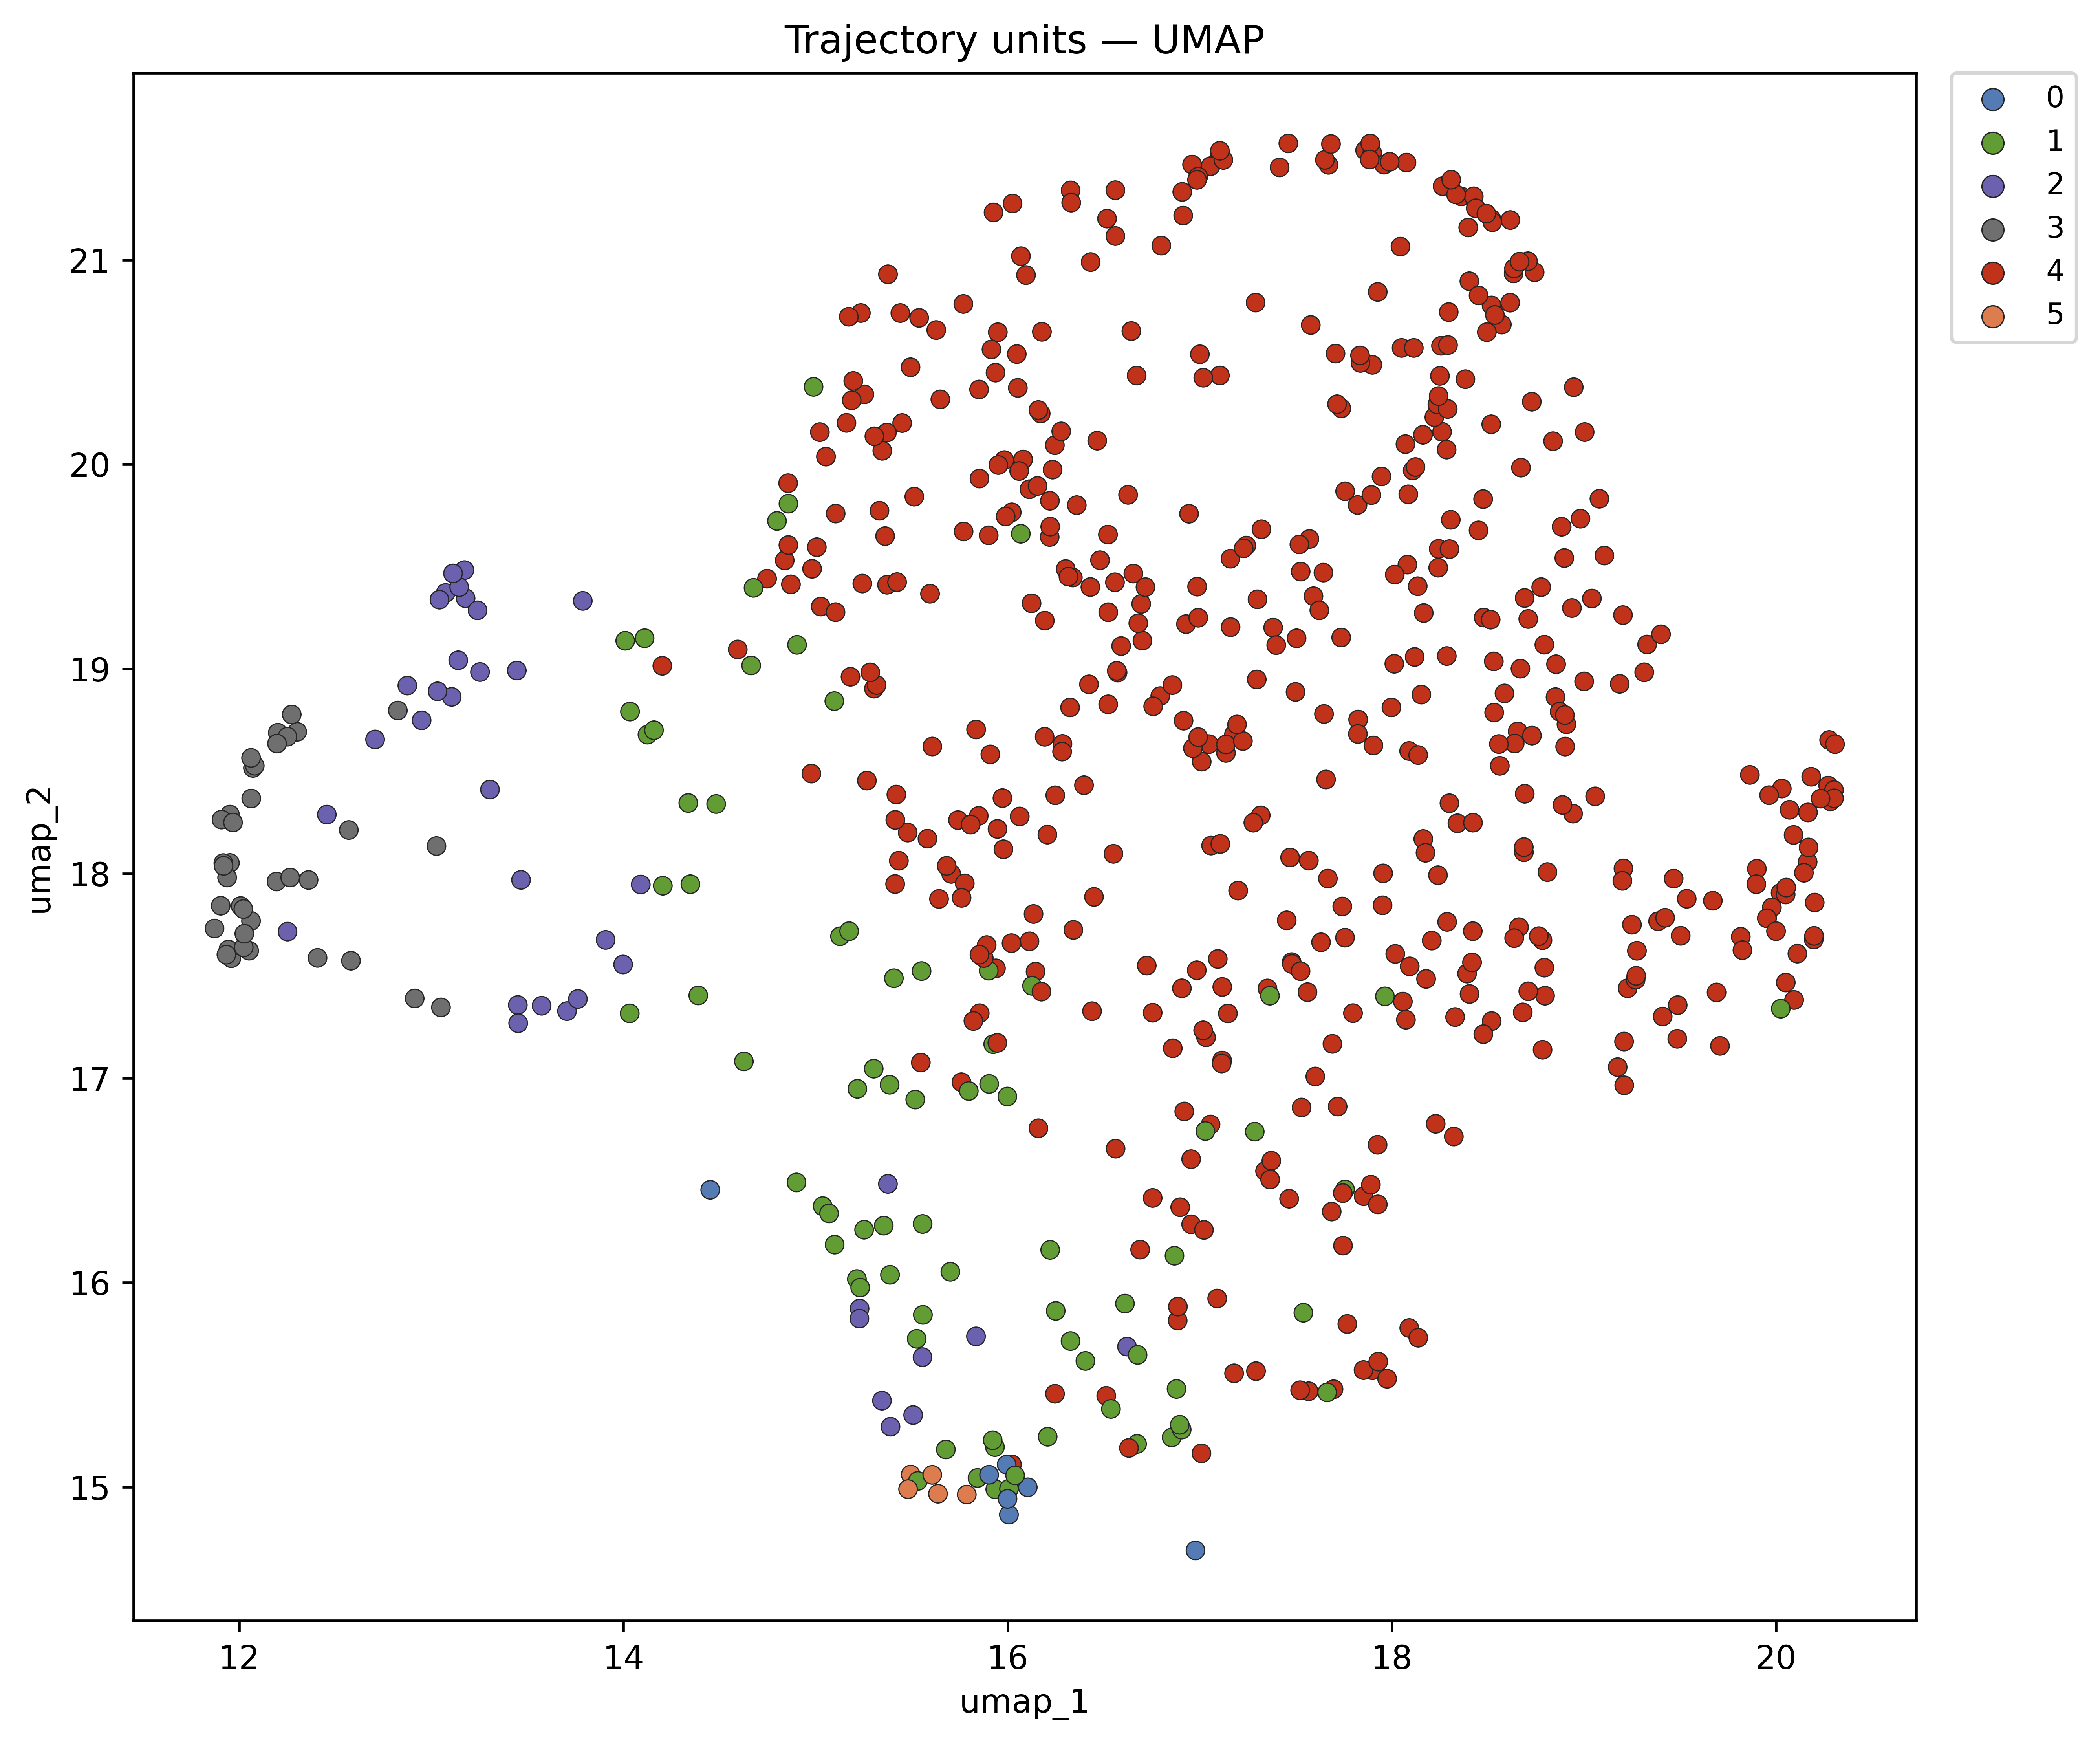

In [6]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, to_rgba

_PAIR_BY_DIMRED = {
    "umap": ("umap_1", "umap_2"),
    "tsne": ("tsne_1", "tsne_2"),
    "pca": ("pca_1", "pca_2"),
}

if DIMRED not in _PAIR_BY_DIMRED:
    raise ValueError(f"DIMRED must be one of {list(_PAIR_BY_DIMRED)}, got {DIMRED!r}")

col_x, col_y = _PAIR_BY_DIMRED[DIMRED]

plt.rcParams["font.sans-serif"] = FONT_SANS
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv(CSV_PATH)
if SELECT_TOPIC is not None:
    df = df.loc[df["topic"] == SELECT_TOPIC].copy()
if COUNTRIES_INCLUDE is not None:
    df = df.loc[df["country"].isin(COUNTRIES_INCLUDE)].copy()

rng = np.random.default_rng(RANDOM_SEED)
plot_x = df[col_x].to_numpy(dtype=float)
plot_y = df[col_y].to_numpy(dtype=float)
if JITTER_STD and JITTER_STD > 0:
    plot_x = plot_x + rng.normal(0.0, JITTER_STD, size=plot_x.shape)
    plot_y = plot_y + rng.normal(0.0, JITTER_STD, size=plot_y.shape)

# Optional manual separation for selected clusters (visual only; does not change source CSV)
_tc = df["trajectory_cluster"].to_numpy()
if SEPARATE_CLUSTER_IDS and SEPARATE_CLUSTER_RADIAL_FACTOR != 1.0:
    _f = float(SEPARATE_CLUSTER_RADIAL_FACTOR)
    _centroids: dict[int, tuple[float, float]] = {}
    for _k in SEPARATE_CLUSTER_IDS:
        _m = _tc == _k
        if np.any(_m):
            _centroids[int(_k)] = (float(plot_x[_m].mean()), float(plot_y[_m].mean()))
    if _centroids:
        _Gx = float(np.mean([c[0] for c in _centroids.values()]))
        _Gy = float(np.mean([c[1] for c in _centroids.values()]))
        for _k, (_cx, _cy) in _centroids.items():
            _m = _tc == _k
            plot_x[_m] += (_f - 1.0) * (_cx - _Gx)
            plot_y[_m] += (_f - 1.0) * (_cy - _Gy)

frame = df.assign(_px=plot_x, _py=plot_y)


def _legend_labels_categorical(series: pd.Series) -> tuple[np.ndarray, dict]:
    cats = pd.Categorical(series)
    codes = cats.codes.copy()
    # map -1 (NaN) to last color bucket as gray
    n_cat = len(cats.categories)
    return codes, {"categories": cats.categories, "n_cat": n_cat}


def _listed_cmap_from_hex(hex_list: list[str]) -> ListedColormap:
    # Discrete qualitative colors (screen + print; defaults are colorblind-oriented).
    return ListedColormap([to_rgba(h) for h in hex_list])


if COLOR_BY == "cluster":
    color_series = frame["trajectory_cluster"]
    hex_src = CLUSTER_PALETTE_HEX if CLUSTER_PALETTE_HEX is not None else _DEFAULT_CLUSTER_HEX_OKABE_ITO
elif COLOR_BY == "country":
    color_series = frame["country"]
    hex_src = COUNTRY_PALETTE_HEX if COUNTRY_PALETTE_HEX is not None else _DEFAULT_COUNTRY_HEX_EXTENDED
else:
    raise ValueError('COLOR_BY must be "cluster" or "country"')

codes, cat_info = _legend_labels_categorical(color_series)
cmap = _listed_cmap_from_hex(hex_src)
n_cat = cat_info["n_cat"]
n_disc = cmap.N
_palette_rgba = np.asarray(cmap.colors)
colors_rgba = np.zeros((len(frame), 4))
valid = codes >= 0
idx_c = codes[valid].astype(np.int64) % n_disc
colors_rgba[valid] = _palette_rgba[idx_c]
colors_rgba[~valid] = to_rgba("#BBBBBB")

title = TITLE or f"Trajectory units — {DIMRED.upper()}"
xlab = XLABEL or col_x
ylab = YLABEL or col_y

fig, ax = plt.subplots(figsize=FIGSIZE_INCH, dpi=DPI)

# 直接统一绘制全部点（包括中美），不再把中美拆出来特殊处理
def _scatter_group(sub: pd.DataFrame, sizes: float, alpha: float, marker: str, z: int, lw: float):
    if sub.empty:
        return
    idx = sub.index
    c = colors_rgba[frame.index.get_indexer(idx)]
    ax.scatter(
        sub["_px"],
        sub["_py"],
        s=sizes,
        c=c,
        marker=marker,
        alpha=alpha,
        linewidths=lw,
        edgecolors=EDGE_COLOR,
        zorder=z,
    )

# 删除对中国和美国点的高亮处理，所有点统一样式
_scatter_group(frame, POINT_SIZE_BASE, ALPHA_BASE, MARKER_OTHERS, ZORDER_BASE, EDGE_WIDTH_BASE)

ax.set_title(title)
ax.set_xlabel(xlab)
ax.set_ylabel(ylab)
if GRID:
    ax.grid(True, alpha=GRID_ALPHA, linestyle="--", linewidth=0.6)
if AXIS_EQUAL:
    ax.set_aspect("equal", adjustable="datalim")

if LEGEND == "auto" and n_cat > 0:
    cats = cat_info["categories"]
    handles = []
    for i, name in enumerate(cats):
        rgba = _palette_rgba[i % n_disc]
        h = ax.scatter([], [], c=[rgba], s=45, label=str(name), edgecolors=EDGE_COLOR, linewidths=0.4)
        handles.append(h)
    kw = {"fontsize": LEGEND_FONT_SIZE}
    if LEGEND_OUTSIDE:
        ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.0, **kw)
    else:
        ax.legend(handles=handles, **kw)
elif LEGEND not in ("auto", "off"):
    raise ValueError('LEGEND must be "auto" or "off"')

fig.tight_layout()

if SAVE_FIG_PATH is not None:
    out = Path(SAVE_FIG_PATH)
    out.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out, dpi=(SAVE_FIG_DPI if SAVE_FIG_DPI is not None else DPI), bbox_inches="tight")
    print("Saved:", out.resolve())

print(
    "rows:", len(frame),
    # 删去对中美高亮数量的输出
    "| topics:", int(frame["topic"].nunique()),
)
plt.show()


## 层次聚类肘部图（UMAP + Agglomerative）

与 `cluster_keybert_from_cluster.ipynb` 中流程一致：对 **SPECTER2 嵌入** 做 **UMAP** 约简，在约简空间上用 **AgglomerativeClustering**（与 `best_agglomerative_params.json` 相同的 linkage/metric）扫描 `n_clusters`，计算 **WCSS**（各簇到质心的平方欧氏距离和）并绘制肘部曲线。

**使用**：先运行下方「肘部图参数」单元，再运行「肘部图计算与绘图」单元。需要已存在 `output/cluster_results/specter2_embeddings_cache.npy` 与 `output/cluster_results/hierarchical_clustering/best_agglomerative_params.json`（由主聚类流程生成）。

In [7]:
# --- Elbow plot parameters (Agglomerative on UMAP, WCSS vs n_clusters) ---

from pathlib import Path

REPO_ROOT = Path.cwd()
EMBEDDINGS_PATH = REPO_ROOT / "output/cluster_results/specter2_embeddings_cache.npy"
BEST_AGGLO_JSON = REPO_ROOT / "output/cluster_results/hierarchical_clustering/best_agglomerative_params.json"
ELBOW_OUT_DIR = REPO_ROOT / "output/visualize"

# Sweep n_clusters: 30, 31, …, 69 (same as range(30, 70, 1))
ELBOW_N_CLUSTERS_RANGE = range(30, 70, 1)
SEED = 42
# Chosen elbow k (figure only; sweep CSV still stores raw WCSS)
ELBOW_CHOICE_K = 50
# For n_clusters > ELBOW_CHOICE_K, plot uses: W_e + factor*(W - W_e); smaller => flatter tail
ELBOW_TAIL_FLATTEN_FACTOR = 0.22


In [8]:
# --- Elbow: WCSS sweep + plot (matches cluster_keybert agglomerative setup) ---

from __future__ import annotations

import json
from collections.abc import Iterable
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.neighbors import kneighbors_graph
from umap import UMAP

from scripts.cluster_pipeline.agglom_pipeline import build_agglomerative_model


def within_cluster_sum_of_squares(X: np.ndarray, labels: np.ndarray) -> float:
    """WCSS in the clustering space (sum of squared distances to per-cluster centroids)."""
    X = np.asarray(X, dtype=np.float64)
    labels = np.asarray(labels)
    total = 0.0
    for k in np.unique(labels):
        mask = labels == k
        block = X[mask]
        if block.shape[0] == 0:
            continue
        centroid = block.mean(axis=0)
        total += float(np.sum((block - centroid) ** 2))
    return total


def run_agglomerative_elbow_sweep(
    reduced: np.ndarray,
    n_clusters_iter: Iterable[int],
    linkage_name: str,
    metric_name: str,
) -> pd.DataFrame:
    """Repeated AgglomerativeClustering with kneighbors connectivity; one WCSS per k."""
    reduced = np.asarray(reduced, dtype=np.float64)
    n_samples = reduced.shape[0]
    n_neighbors_conn = max(2, min(30, n_samples - 1))
    conn = kneighbors_graph(reduced, n_neighbors=n_neighbors_conn, include_self=False)

    rows: list[dict] = []
    for k in n_clusters_iter:
        k = int(k)
        if k < 2 or k > n_samples:
            rows.append({"n_clusters": k, "wcss": np.nan, "status": "skip_range"})
            continue
        try:
            model = build_agglomerative_model(
                n_clusters=k,
                linkage_name=linkage_name,
                metric_name=metric_name,
                connectivity=conn,
            )
            labels = model.fit_predict(reduced)
            wcss = within_cluster_sum_of_squares(reduced, labels)
            rows.append({"n_clusters": k, "wcss": wcss, "status": "ok"})
        except Exception as exc:
            rows.append({"n_clusters": k, "wcss": np.nan, "status": f"error:{exc}"})

    return pd.DataFrame(rows)


def plot_agglomerative_elbow_curve(
    elbow_df: pd.DataFrame,
    *,
    title: str,
    save_path: Path | None = None,
    figsize: tuple[float, float] = (9, 5.5),
    elbow_k: int | None = 50,
    tail_flatten_factor: float = 0.22,
) -> tuple[plt.Figure, plt.Axes]:
    """Plot elbow curve. Sweep CSV is unchanged; y for n>elbow_k can be compressed for display."""
    ok_mask = elbow_df["status"] == "ok"
    d = elbow_df.loc[ok_mask, ["n_clusters", "wcss"]].sort_values("n_clusters")
    n = d["n_clusters"].to_numpy(dtype=float)
    w = d["wcss"].to_numpy(dtype=float)
    w_plot = w.astype(np.float64, copy=True)
    subtitle = ""
    if elbow_k is not None and tail_flatten_factor != 1.0:
        hit = n == float(elbow_k)
        if np.any(hit):
            w_e = float(w[hit][0])
            tail = n > float(elbow_k)
            w_plot[tail] = w_e + (w[tail] - w_e) * float(tail_flatten_factor)
            subtitle = (
                f"(display: for n>{elbow_k}, WCSS excess ×{tail_flatten_factor}; CSV = raw WCSS)"
            )

    fig, ax = plt.subplots(figsize=figsize, dpi=120)
    line_color = "#9998FF"
    elbow_color = "#FF9A9B"
    ax.plot(n, w_plot, color=line_color, lw=2.2, zorder=1)
    if elbow_k is not None and np.any(n == float(elbow_k)):
        ek = float(elbow_k)
        w_el = float(w_plot[n == ek][0])
        mask = n != ek
        ax.scatter(n[mask], w_plot[mask], s=26, c=line_color, marker="o", zorder=2, edgecolors="none")
        ax.scatter(
            [ek],
            [w_el],
            s=320,
            zorder=5,
            c=elbow_color,
            marker="*",
            edgecolors="0.35",
            linewidths=0.6,
        )
        ax.annotate(
            f"n_clusters={elbow_k}",
            xy=(ek, w_el),
            xytext=(12, 14),
            textcoords="offset points",
            fontsize=10,
            color="#333333",
        )
    else:
        ax.scatter(n, w_plot, s=26, c=line_color, marker="o", zorder=2, edgecolors="none")
    ax.set_xlabel("n_clusters")
    ax.set_ylabel("Within-cluster sum of squares (WCSS)")
    full_title = title + (f"\n{subtitle}" if subtitle else "")
    ax.set_title(full_title, fontsize=10)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=600, bbox_inches="tight")
    return fig, ax


embeddings = np.load(EMBEDDINGS_PATH)

with open(BEST_AGGLO_JSON, encoding="utf-8") as f:
    best = json.load(f)

umap_model = UMAP(
    n_neighbors=int(best["umap_n_neighbors"]),
    n_components=int(best["umap_n_components"]),
    min_dist=float(best["umap_min_dist"]),
    metric=str(best["umap_metric"]),
    random_state=SEED,
    low_memory=True,
)
reduced = umap_model.fit_transform(embeddings)

linkage_name = str(best["agglom_linkage"])
metric_name = str(best["agglom_metric"])

# elbow_df = run_agglomerative_elbow_sweep(
#     reduced,
#     ELBOW_N_CLUSTERS_RANGE,
#     linkage_name,
#     metric_name,
# )

In [9]:

ELBOW_OUT_DIR.mkdir(parents=True, exist_ok=True)
csv_path = ELBOW_OUT_DIR / "agglomerative_elbow_wcss_sweep.csv"
elbow_df.to_csv(csv_path, index=False)
print("Saved sweep CSV:", csv_path.resolve())

_elbow_title = (
    "Elbow: AgglomerativeClustering on UMAP reduced embeddings\n"
    f"UMAP(n_neighbors={best['umap_n_neighbors']}, n_components={best['umap_n_components']}, "
    f"min_dist={best['umap_min_dist']}, metric={best['umap_metric']}) | "
    f"Agglo(linkage={linkage_name}, metric={metric_name})"
)
png_path = ELBOW_OUT_DIR / "agglomerative_elbow_n_clusters.png"
plot_agglomerative_elbow_curve(
    elbow_df,
    title=_elbow_title,
    save_path=png_path,
    elbow_k=ELBOW_CHOICE_K,
    tail_flatten_factor=ELBOW_TAIL_FLATTEN_FACTOR,
)
print("Saved figure:", png_path.resolve())
plt.show()

NameError: name 'elbow_df' is not defined